In [6]:
import geopandas as gpd

# Load your new data
roads_raw = gpd.read_file(r'D:\landslide\road\roads.shp') # Example name from BBBike
rivers_raw = gpd.read_file(r'D:\landslide\HydroRIVERS_v10_as_shp\HydroRIVERS_v10_as.shp') # Example name from HydroRIVERS
tehri_boundary = gpd.read_file(r'D:\landslide\Tehri_bound\tehri_boundary.shp')

# Transform all to UTM Zone 44N (Metric)
# This is crucial for accurate scale bars and 10m modeling
roads = roads_raw.to_crs("EPSG:32644")
rivers = rivers_raw.to_crs("EPSG:32644")
tehri = tehri_boundary.to_crs("EPSG:32644")

# Clip the global HydroRIVERS data to just Tehri
rivers_tehri = gpd.clip(rivers, tehri)
roads_tehri = gpd.clip(roads, tehri)

# Save the clipped data for future use
rivers_tehri.to_file(r'D:\landslide\Tehri_rivers\tehri_rivers.shp')
roads_tehri.to_file(r'D:\landslide\Tehri_roads\tehri_roads.shp')

# Study Area(Tehri Garhwal)

C:\Users\sangh\AppData\Local\Temp\ipykernel_18252\2458724766.py:28: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  world = gpd.GeoDataFrame({'geometry': [tehri.unary_union.envelope.buffer(50000)]}, crs=tehri.crs)
C:\Users\sangh\AppData\Local\Temp\ipykernel_18252\2458724766.py:60: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax_main.legend(loc='lower left', frameon=True, fontsize=11, facecolor='white', edgecolor='black', title="Legend")


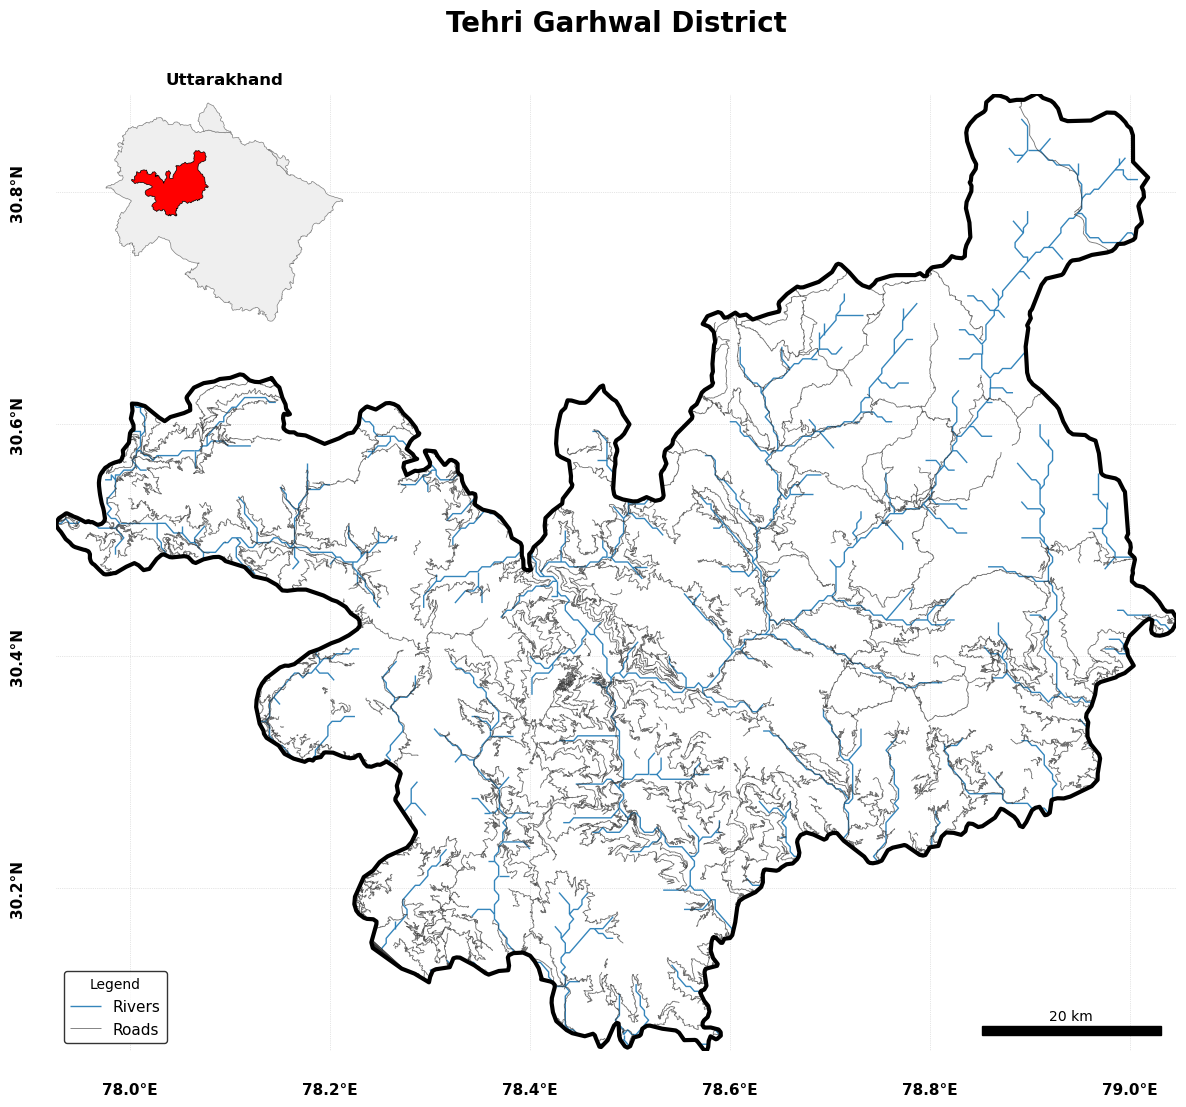

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import numpy as np
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

# 1. Load Data
tehri = gpd.read_file(r'D:\landslide\Tehri_bound\tehri_boundary_utm.shp').to_crs(epsg=3857)
india_states = gpd.read_file(r'D:\landslide\tehri_landslide\data\gadm41_IND_shp\gadm41_IND_1.shp').to_crs(epsg=3857)
roads_raw = gpd.read_file(r'D:\landslide\Tehri_roads\tehri_roads.shp').to_crs(epsg=3857)
rivers_raw = gpd.read_file(r'D:\landslide\Tehri_rivers\tehri_rivers.shp').to_crs(epsg=3857)

# --- FILTERING ---
roads_raw = roads_raw[roads_raw.geometry.length < 20000]
uttarakhand = india_states[india_states['NAME_1'] == 'Uttarakhand'].copy()
roads = gpd.clip(roads_raw, tehri)
rivers = gpd.clip(rivers_raw, tehri)

# 2. Setup Figure
fig = plt.figure(figsize=(14, 12), facecolor='white')
ax_main = fig.add_axes([0.1, 0.1, 0.8, 0.8]) 

# --- INSET POSITION FIX: Moved higher to 0.72 ---
# [left, bottom, width, height]
ax_in_uk = fig.add_axes([0.12, 0.70, 0.20, 0.20]) 

# --- MAIN MAP ---
world = gpd.GeoDataFrame({'geometry': [tehri.unary_union.envelope.buffer(50000)]}, crs=tehri.crs)
mask = gpd.overlay(world, tehri, how='difference')

cx.add_basemap(ax_main, source=cx.providers.Esri.WorldTopoMap, zoom=12, zorder=0, attribution=False)
mask.plot(ax=ax_main, color='white', alpha=1.0, zorder=1)

rivers.plot(ax=ax_main, color='#1f78b4', linewidth=1.0, alpha=0.9, zorder=2, label='Rivers')
roads.plot(ax=ax_main, color='#333333', linewidth=0.6, alpha=0.7, zorder=2, label='Roads')
tehri.plot(ax=ax_main, facecolor='none', edgecolor='black', linewidth=3, zorder=3, label='District Boundary')

# Axis Locking
xmin, ymin, xmax, ymax = tehri.total_bounds
ax_main.set_xlim(xmin, xmax)
ax_main.set_ylim(ymin, ymax)

# --- COORDINATES ---
lons = np.arange(78.0, 79.2, 0.2)
lats = np.arange(30.2, 31.2, 0.2)

for lon in lons:
    x, _ = gpd.points_from_xy([lon], [30.5], crs="EPSG:4326").to_crs(epsg=3857)[0].coords[0]
    if xmin < x < xmax:
        ax_main.text(x, ymin - 3500, f"{lon:.1f}°E", ha='center', va='top', fontsize=11, fontweight='bold')
        ax_main.axvline(x, color='gray', linestyle=':', linewidth=0.5, alpha=0.4, zorder=1)

for lat in lats:
    _, y = gpd.points_from_xy([78.5], [lat], crs="EPSG:4326").to_crs(epsg=3857)[0].coords[0]
    if ymin < y < ymax:
        ax_main.text(xmin - 3500, y, f"{lat:.1f}°N", ha='right', va='center', rotation=90, fontsize=11, fontweight='bold')
        ax_main.axhline(y, color='gray', linestyle=':', linewidth=0.5, alpha=0.4, zorder=1)

# --- LEGEND & SCALE ---
ax_main.legend(loc='lower left', frameon=True, fontsize=11, facecolor='white', edgecolor='black', title="Legend")

scalebar = AnchoredSizeBar(ax_main.transData, 20000, '20 km', 'lower right', 
                           pad=1.0, color='black', frameon=False, size_vertical=1000, label_top=True)
ax_main.add_artist(scalebar)

ax_main.set_axis_off()
ax_main.set_title("Tehri Garhwal District", fontsize=20, fontweight='bold', pad=45)

# --- INSET PLOT ---
uttarakhand.plot(ax=ax_in_uk, color='#efefef', edgecolor='grey', linewidth=0.5)
tehri.plot(ax=ax_in_uk, color='red', edgecolor='black', linewidth=0.5)
ax_in_uk.set_axis_off()
ax_in_uk.set_title("Uttarakhand", fontsize=12, fontweight='bold')

plt.savefig('figures/Tehri_Final_Map_Perfected.png', dpi=300, bbox_inches='tight')
plt.show()

# Landslide Points

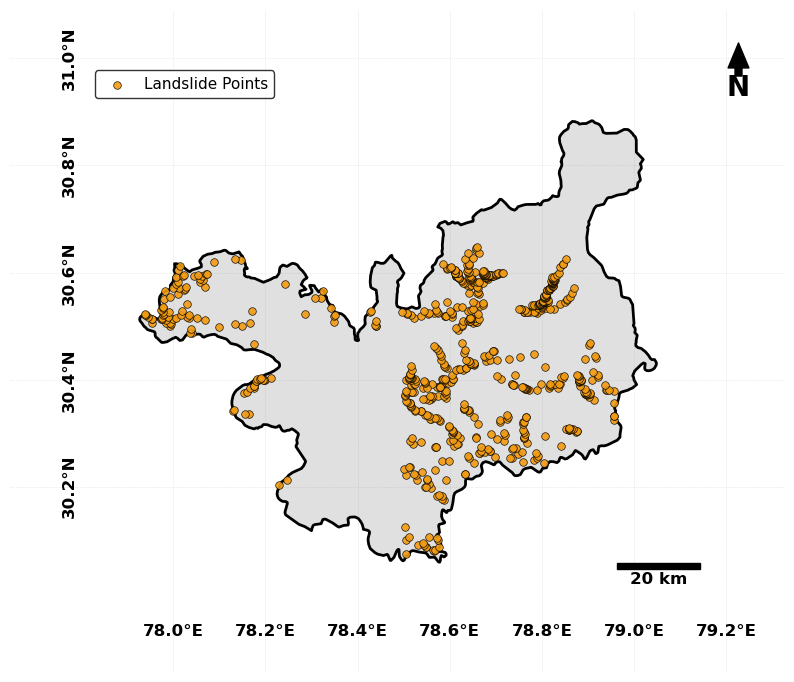

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import numpy as np

# 1. Load Data
tehri = gpd.read_file(r'D:\landslide\Tehri_bound\tehri_boundary_utm.shp').to_crs(epsg=3857)
landslide_raw = gpd.read_file(r'D:\landslide\geospatialmaps\Landslide Point.shp').to_crs(epsg=3857)

# --- CRITICAL: CLIP DATA ---
# This ensures only points inside the boundary are processed
landslide_points = gpd.clip(landslide_raw, tehri)

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(10, 10), facecolor='white')

# 3. Plot Layers
tehri.plot(ax=ax, color='#e0e0e0', edgecolor='black', linewidth=2, zorder=1)
landslide_points.plot(ax=ax, color='#f39c12', edgecolor='black', linewidth=0.5, 
                       markersize=30, alpha=0.9, zorder=2, label='Landslide Points')

# --- COORDINATE AND LIMITS FIX ---
xmin, ymin, xmax, ymax = tehri.total_bounds
width = xmax - xmin
height = ymax - ymin

# 25% padding to keep the district centered and small
ax.set_xlim(xmin - 0.25*width, xmax + 0.25*width)
ax.set_ylim(ymin - 0.25*height, ymax + 0.25*height)

lons = np.arange(78.0, 79.2, 0.2)
lats = np.arange(30.2, 31.0, 0.2)

for lon in lons:
    x_pos, _ = gpd.points_from_xy([lon], [30.5], crs="EPSG:4326").to_crs(epsg=3857)[0].coords[0]
    if ax.get_xlim()[0] < x_pos < ax.get_xlim()[1]:
        ax.axvline(x_pos, color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
        ax.text(x_pos, ymin - 15000, f"{lon:.1f}°E", ha='center', va='top', fontweight='bold', fontsize=12)

for lat in lats:
    _, y_pos = gpd.points_from_xy([78.5], [lat], crs="EPSG:4326").to_crs(epsg=3857)[0].coords[0]
    if ax.get_ylim()[0] < y_pos < ax.get_ylim()[1]:
        ax.axhline(y_pos, color='gray', linestyle=':', linewidth=0.5, alpha=0.3)
        ax.text(xmin - 15000, y_pos, f"{lat:.1f}°N", ha='right', va='center', fontweight='bold', rotation=90, fontsize=12)

# --- NORTH ARROW (Top Right) ---
nx, ny = 0.94, 0.90
ax.annotate('', xy=(nx, ny + 0.05), xytext=(nx, ny),
            arrowprops=dict(facecolor='black', width=5, headwidth=15, headlength=18),
            xycoords='axes fraction')
ax.text(nx, ny - 0.03, 'N', transform=ax.transAxes, fontsize=20, fontweight='bold', ha='center')

# --- SCALE BAR ---
scalebar = AnchoredSizeBar(ax.transData, 20000, '20 km', 'lower right', 
                           pad=5.0, color='black', frameon=False, size_vertical=1500,
                           fontproperties=fm.FontProperties(size=12, weight='bold'))
ax.add_artist(scalebar)

# --- LEGEND FIX: UPPER LEFT ---
# bbox_to_anchor coordinates are (x, y). 
# (0.1, 0.9) moves it 10% in from left and 90% up from bottom.
ax.legend(loc='upper left', bbox_to_anchor=(0.1, 0.92), frameon=True, 
          facecolor='white', edgecolor='black', fontsize=11)

ax.set_axis_off()
#plt.savefig('Tehri_Inventory_UpperLeft_Legend.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import joblib

# 1. Load your Best Model (e.g., XGBoost or RF)
model = joblib.load('best_landslide_model.pkl')

# 2. Load your full study area data (every 10m pixel)
# This should contain the 14 factors for every pixel in Tehri Garhwal
full_area_df = pd.read_csv('tehri_full_grid_10m.csv') 
features = ['slope', 'elevation', 'rainfall', 'dist_road', ...] # your 14 factors

# 3. Generate Predictions (LSI)
full_area_df['LSI'] = model.predict_proba(full_area_df[features])[:, 1]

# 4. Classify LSI into 5 Zones using Natural Breaks (equivalent to ArcGIS Jenks)
# Note: You can also use fixed thresholds if you've already defined them
import jenkspy
breaks = jenkspy.jenks_breaks(full_area_df['LSI'], nb_class=5)
labels = ['Very Low', 'Low', 'Moderate', 'High', 'Very High']
full_area_df['LSZ'] = pd.cut(full_area_df['LSI'], bins=breaks, labels=labels, include_lowest=True)

# --- FIGURE 7: AREA DISTRIBUTION PERCENTAGES ---
area_dist = full_area_df['LSZ'].value_counts(normalize=True) * 100
print("--- Area Distribution (%) ---")
print(area_dist)

# --- FIGURE 8: LANDSLIDE DENSITY (VALIDATION) ---
# Load your 2,661 landslide points and extract the LSZ they fall into
inventory_df = pd.read_csv('landslide_inventory_points.csv') 
# Extract values from the predicted grid at landslide locations
# (Or predict specifically for the 2,661 points)
inventory_df['pred_LSZ'] = model.predict_proba(inventory_df[features])[:, 1]
inventory_df['LSZ_Class'] = pd.cut(inventory_df['pred_LSZ'], bins=breaks, labels=labels, include_lowest=True)

landslide_counts = inventory_df['LSZ_Class'].value_counts()
print("\n--- Landslide Counts per Zone (nLs) ---")
print(landslide_counts)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.metrics import roc_curve, auc

# 1. SETUP
# Use your testing dataset (30% split) for validation
test_df = pd.read_csv("Tehri_Testing_Data.csv") 
model_dir = r"D:\landslide\models"
model_names = ['Logistic_Regression', 'Random_Forest', 'XGBoost', 'LightGBM']

# Ensure features match your training set
features = [col for col in test_df.columns if col not in ['x', 'y', 'landslide_id', 'label', 'TRI', 'BSI']]
y_true = test_df['label']

# 2. PLOTTING SETUP
plt.figure(figsize=(10, 8))
colors = ['#2ca02c', '#1f77b4', '#d62728', '#9467bd'] # Green, Blue, Red, Purple

print("Generating ROC Curves...")

for i, name in enumerate(model_names):
    model_path = os.path.join(model_dir, f"Tehri_LSM_{name}.pkl")
    model_pipe = joblib.load(model_path)
    
    # Get predicted probabilities for the positive class (landslide = 1)
    y_score = model_pipe.predict_proba(test_df[features])[:, 1]
    
    # Calculate False Positive Rate, True Positive Rate, and AUC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # Plotting each model's curve
    plt.plot(fpr, tpr, color=colors[i], lw=2, 
             label=f'{name.replace("_", " ")} (AUC = {roc_auc:.4f})')

# 3. FORMATTING (Mirroring Figure 9 in Chauhan et al. 2025)
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--') # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (%)', fontsize=12)
plt.ylabel('True Positive Rate (%)', fontsize=12)
plt.title('ROC Curves of Landslide Susceptibility Models (Tehri District)', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)

# Save the figure
plt.savefig(os.path.join(model_dir, "ROC_Curve_Validation.png"), dpi=300)
plt.show()

print(f"ROC curve saved to {model_dir}")

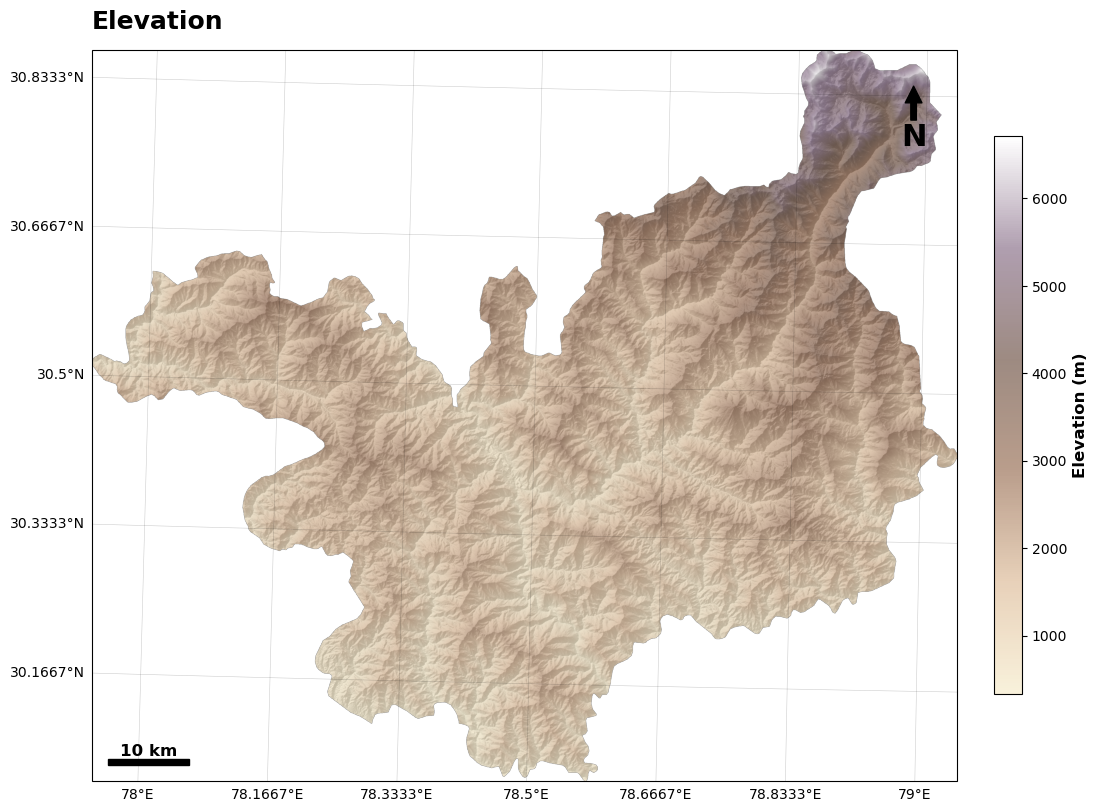

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.colors import LinearSegmentedColormap
import os

# --- 1. CONFIGURATION ---
feat_path = r"D:\landslide\final_data\Elevation_10m.tif"
dem_path = r"D:\landslide\tehri_landslide\data\DEM\DEM_Tehri_fixed.tif"
output_viz_folder = r"D:\landslide\Feature_Visuals"
data_crs = ccrs.UTM(zone=44)

# Recreating the Chauhan et al. (2025) Elevation Ramp:
# Earth-yellow -> Brown -> Purple -> White (for snow peaks)
colors = ["#f5e9c4", "#d9b38c", "#8c5d3f", "#5c3d2e", "#7b5e7b", "#ffffff"]
nodes = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
chauhan_elev_cmap = LinearSegmentedColormap.from_list("chauhan_elev", list(zip(nodes, colors)))

# --- 2. DATA LOADING ---
with rasterio.open(feat_path) as src:
    target_factor = 0.33
    out_h, out_w = int(src.height * target_factor), int(src.width * target_factor)
    elev_data = src.read(1, out_shape=(1, out_h, out_w), resampling=rasterio.enums.Resampling.bilinear)
    elev_data = np.ma.masked_where(elev_data <= -9999, elev_data)
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

# Generate Hillshade for the 3D "texture" background
ls = plt.matplotlib.colors.LightSource(azdeg=315, altdeg=45)
hillshade = ls.hillshade(elev_data.astype(np.float32), vert_exag=1.5)

# --- 3. PLOTTING ---
fig = plt.figure(figsize=(12, 10), facecolor='white')
ax = plt.axes(projection=data_crs)
ax.set_extent(extent, crs=data_crs)

# Layer 1: Hillshade (The gray texture)
ax.imshow(hillshade, extent=extent, cmap='gray', origin='upper', alpha=0.5, transform=data_crs)

# Layer 2: Elevation (The Chauhan color ramp)
im = ax.imshow(elev_data, extent=extent, cmap=chauhan_elev_cmap, origin='upper', alpha=0.6, transform=data_crs)

# Geographic Gridlines
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False, 
                  linewidth=0.4, color='black', alpha=0.2)
gl.top_labels = gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER

# North Arrow
ax.annotate('N', xy=(0.95, 0.95), xytext=(0.95, 0.88),
            arrowprops=dict(facecolor='black', width=4, headwidth=12),
            ha='center', va='center', fontsize=22, fontweight='bold', xycoords=ax.transAxes)

# Scale Bar (Approximate for Tehri region)
ax.add_patch(plt.Rectangle((extent[0]+2000, extent[2]+2000), 10000, 800, color='black', transform=data_crs))
ax.text(extent[0]+7000, extent[2]+3200, '10 km', transform=data_crs, ha='center', fontsize=12, fontweight='bold')

# Colorbar (Legend)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Elevation (m)', fontweight='bold', size=12)

plt.title('Elevation', loc='left', fontsize=18, fontweight='bold', pad=15)
plt.savefig(os.path.join(output_viz_folder, "Elevation.png"), dpi=400, bbox_inches='tight')
plt.show()